In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Loading the data

In [4]:
df = pd.read_csv("../data/imputed_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.set_index('Timestamp', drop=True)
df.sort_index(inplace=True)

## Choosing exogenous predictors

`AutoReg` can take other variables as exogenous regressors alongside AC's own lags. We pick the columns most physically tied to AC output

In [5]:
exog_cols = [
       'Wind_Dir_deg', 'Wind_Speed_ms', 'Humidity_pct',
       'Outdoor_Temp_C', 'Solar_Radiation_Wm2',
       'PM10_ugm3', 'PM25_ugm3', 'Rain_mm',
       'dew_point_2m (°C)'
]

df[['DC'] + exog_cols].corr()['DC']

DC                     1.000000
Wind_Dir_deg          -0.183805
Wind_Speed_ms          0.214277
Humidity_pct          -0.290730
Outdoor_Temp_C         0.235853
Solar_Radiation_Wm2    0.972456
PM10_ugm3             -0.062695
PM25_ugm3             -0.056337
Rain_mm               -0.054337
dew_point_2m (°C)     -0.068966
Name: DC, dtype: float64

# Splitting the data

Train: (5152, 12), Test: (1471, 12), Validation: (737, 12)


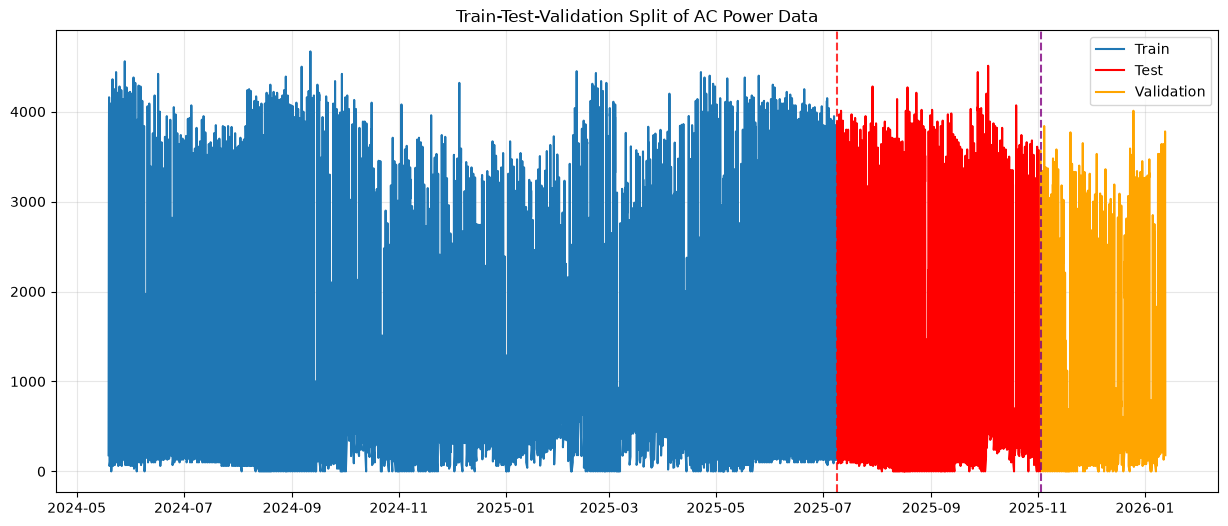

In [6]:
train_percent = 0.7
test_percent = 0.2

n_total = len(df)
train_end_index = int(n_total * train_percent)
test_end_index = int(n_total * (train_percent + test_percent))

train_df = df.iloc[:train_end_index]
test_df = df.iloc[train_end_index:test_end_index]
validation_df = df.iloc[test_end_index:]

split_time_1 = train_df.index.max()
split_time_2 = test_df.index.max()

print(f"Train: {train_df.shape}, Test: {test_df.shape}, Validation: {validation_df.shape}")

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, train_df['DC'], label='Train')
plt.plot(test_df.index, test_df['DC'], label='Test', color='red')
plt.plot(validation_df.index, validation_df['DC'], label='Validation', color='orange')
plt.axvline(split_time_1, color='red', linestyle='--', alpha=0.8)
plt.axvline(split_time_2, color='purple', linestyle='--', alpha=0.8)
plt.title('Train-Test-Validation Split of AC Power Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## RangeIndex for modeling

Same issue as the pure AR notebook: the daytime-only filtering leaves irregular gaps between rows, so there's no fixed frequency for `statsmodels` to infer. We fit on a plain `RangeIndex` and reattach real dates only for plotting.

In [7]:
train_series = train_df['DC'].reset_index(drop=True)
train_exog = train_df[exog_cols].reset_index(drop=True)

test_series = test_df['DC'].reset_index(drop=True)
test_exog = test_df[exog_cols].reset_index(drop=True)

# Choosing the right lag order p

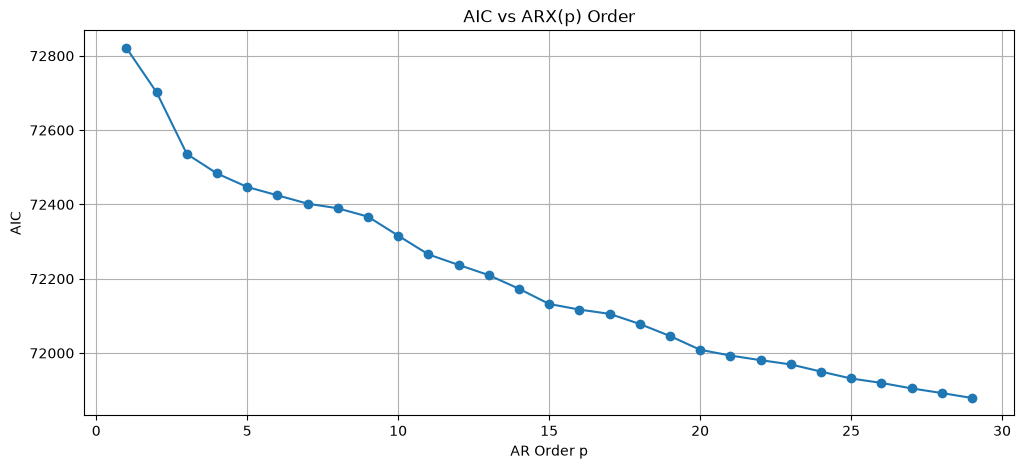

In [8]:
aic_values = []
p_range = range(1, 30)

for p in p_range:
    try:
        m = AutoReg(train_series, lags=p, exog=train_exog).fit()
        aic_values.append(m.aic)
    except Exception as e:
        print(f"p={p} failed: {e}")
        aic_values.append(None)

plt.figure(figsize=(12, 5))
plt.plot(p_range, aic_values, marker='o')
plt.xlabel('AR Order p')
plt.ylabel('AIC')
plt.title('AIC vs ARX(p) Order')
plt.grid(True)
plt.show()

In [9]:
sel = ar_select_order(train_series, exog=train_exog, maxlag=50, ic='aic', trend='c')
print("Best lag(s):", sel.ar_lags)

final_model = sel.model.fit()
print(final_model.summary())

Best lag(s): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
                            AutoReg Model Results                             
Dep. Variable:                     DC   No. Observations:                 5122
Model:                  AutoReg-X(30)   Log Likelihood              -35889.223
Method:               Conditional MLE   S.D. of innovations            267.184
Date:                Wed, 23 Sep 2026   AIC                          71860.445
Time:                        15:43:14   BIC                          72128.638
Sample:                            30   HQIC                         71954.328
                                 5152                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 190.4827     57.495      3.313      0.001    

In [10]:
print("Best lag(s):", sel.ar_lags)

Best lag(s): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


# Test-set forecast

Predicting out-of-sample requires future values of the exogenous variables too (`exog_oos`) — in production these would come from a weather forecast; here we use the known test-set values to evaluate the model itself.

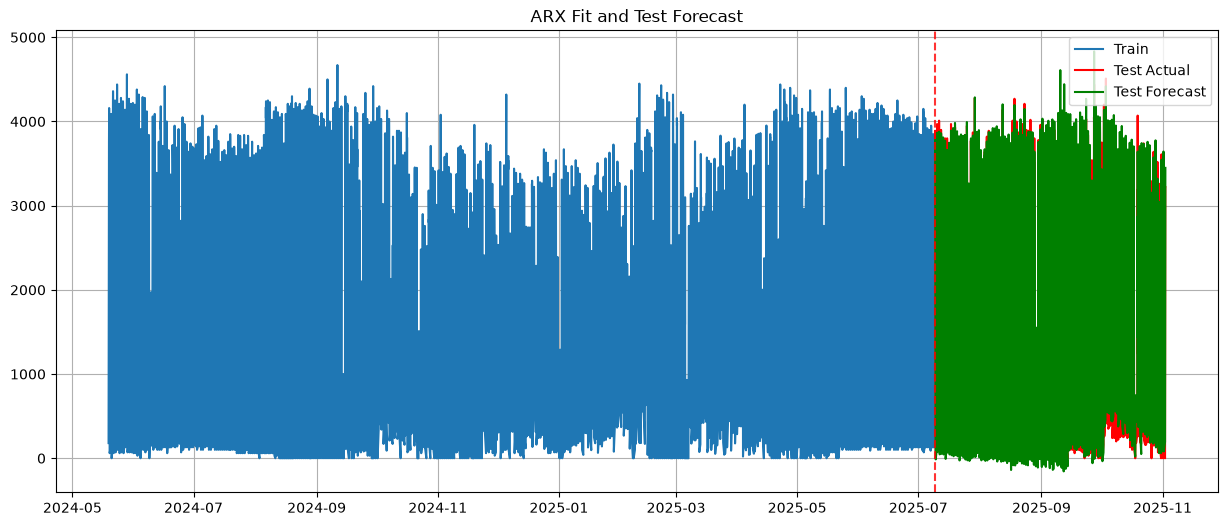

In [11]:
start = len(train_series)
end = start + len(test_series) - 1

pred_test = final_model.predict(start=start, end=end, dynamic=False, exog_oos=test_exog)
pred_test.index = test_df.index

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, train_df['DC'], label='Train')
plt.plot(test_df.index, test_df['DC'], label='Test Actual', color='red')
plt.plot(pred_test.index, pred_test, label='Test Forecast', color='green')
plt.axvline(split_time_1, color='red', linestyle='--', alpha=0.8)
plt.title('ARX Fit and Test Forecast')
plt.legend()
plt.grid(True)
plt.show()

## Model diagnostics

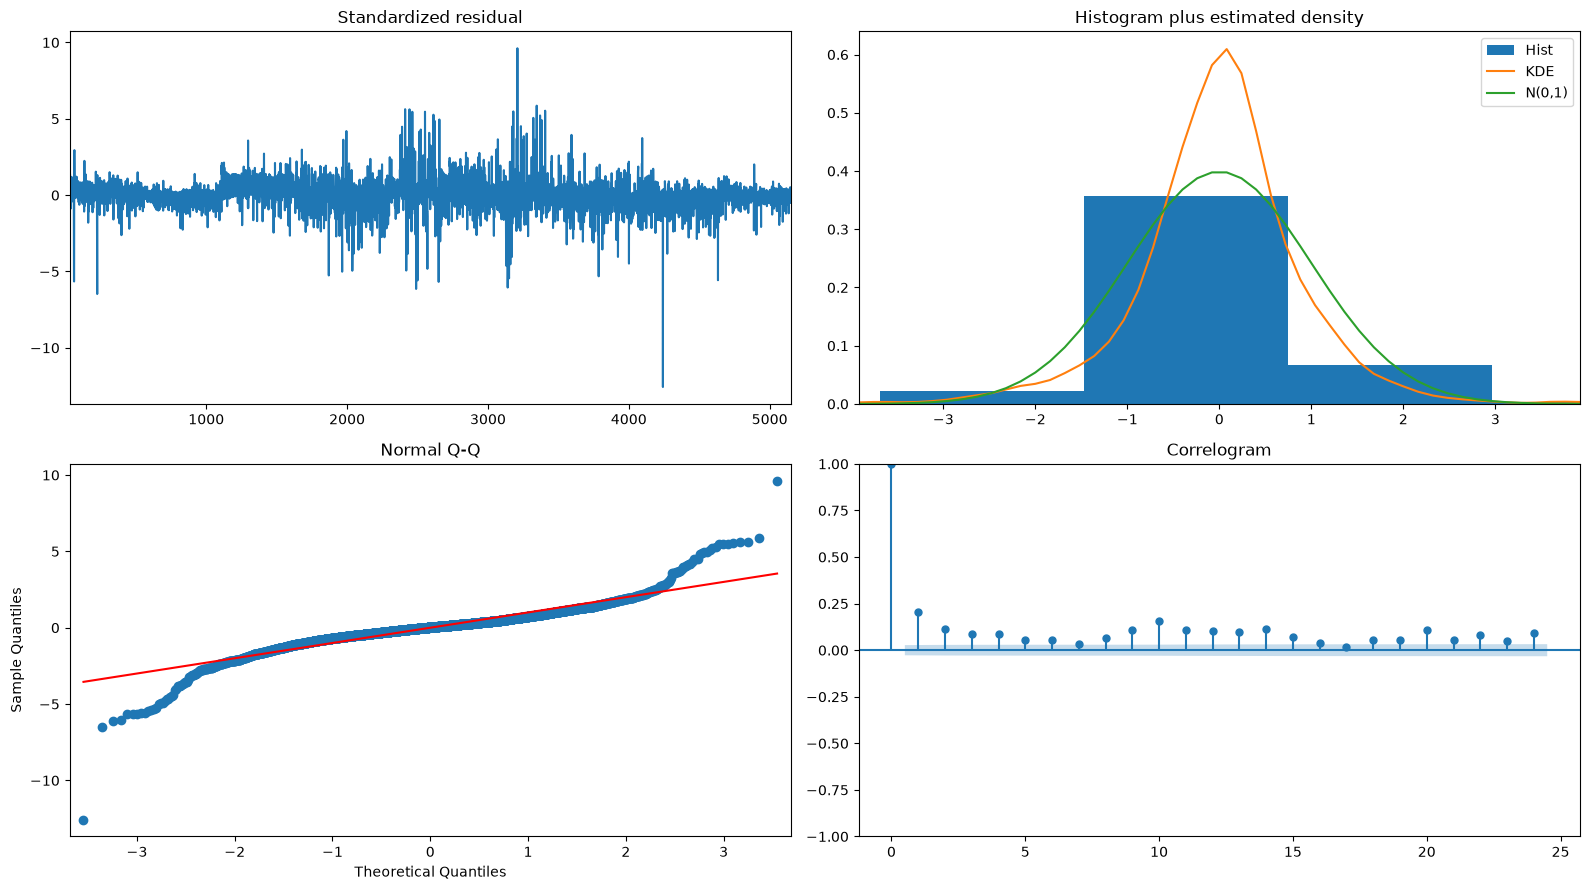

In [12]:
fig = plt.figure(figsize=(16, 9))
fig = final_model.plot_diagnostics(fig=fig, lags=24)
plt.tight_layout()
plt.show()

## Rolling one-step-ahead forecast on the test set

In [13]:
ac_full = pd.concat([train_df['DC'], test_df['DC']]).reset_index(drop=True)
exog_full = pd.concat([train_df[exog_cols], test_df[exog_cols]]).reset_index(drop=True)

ar_predictions = []
n_train = len(train_df)

for i in range(n_train, n_train + len(test_df)):
    updated_res = final_model.apply(ac_full[:i], exog=exog_full[:i])
    next_exog = exog_full.iloc[[i]]
    ar_predictions.append(updated_res.forecast(1, exog=next_exog).iloc[0])

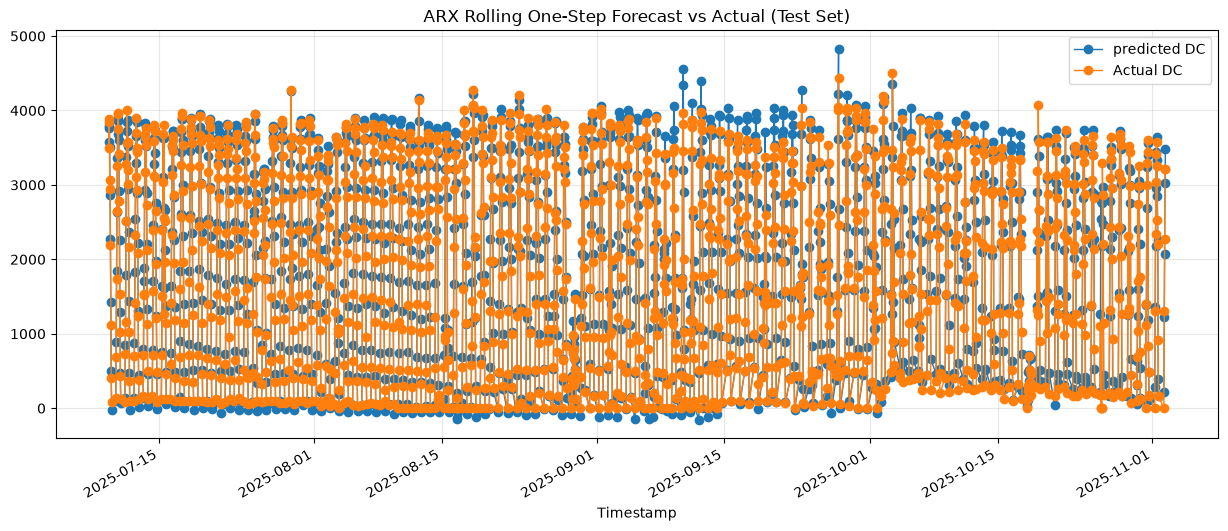

In [14]:
predictions = pd.DataFrame({
    "predicted DC": ar_predictions,
    "Actual DC": test_df['DC'].values,
}, index=test_df.index)

_, ax = plt.subplots(figsize=(15, 6))
predictions.plot(ax=ax, marker='o', linestyle='-', linewidth=1)
plt.title('ARX Rolling One-Step Forecast vs Actual (Test Set)')
plt.grid(True, alpha=0.3)
plt.show()

## Evaluation metrics

In [15]:
mse = mean_squared_error(predictions['Actual DC'], predictions['predicted DC'])
print('Test MSE: %.5f' % mse)

mape = np.mean(np.abs((predictions['Actual DC'] - predictions['predicted DC']) / (predictions['Actual DC'] + 1)))
print('Test MAPE-like: %.3f' % mape)

mae = mean_absolute_error(predictions['Actual DC'], predictions['predicted DC'])
print('Test MAE: %.3f' % mae)

r2 = r2_score(predictions['Actual DC'], predictions['predicted DC'])
print(f'R²: {r2:.3f}')

Test MSE: 87437.65652
Test MAPE-like: 9.975
Test MAE: 185.648
R²: 0.951


## Validation set forecast

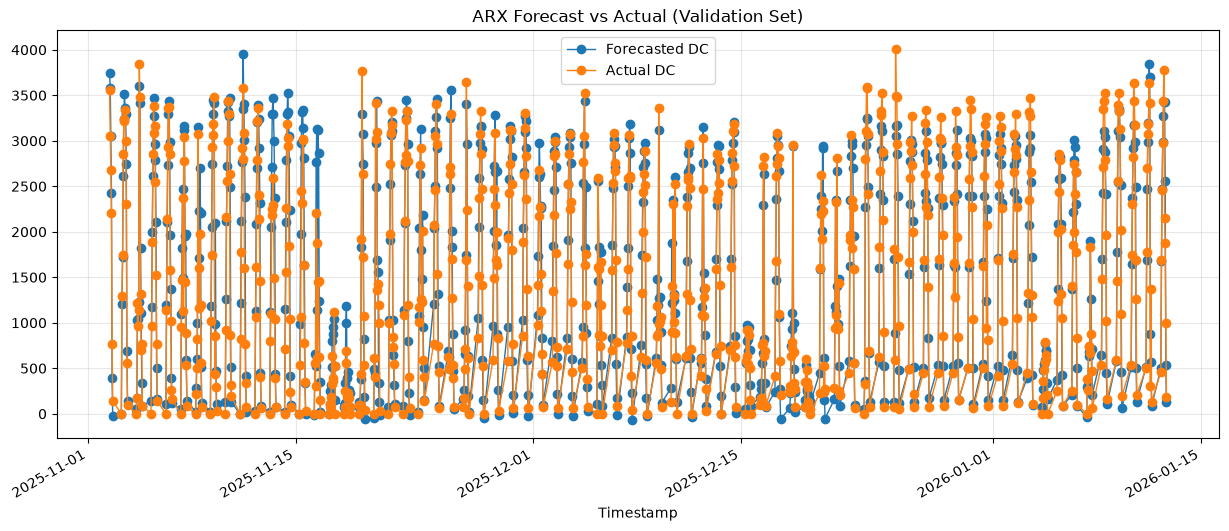

In [16]:
validation_exog = validation_df[exog_cols].reset_index(drop=True)

forecast_values = final_model.forecast(validation_df['DC'].size, exog=validation_exog)
forecast_values.index = validation_df.index

predictions_val = pd.DataFrame({
    "Forecasted DC": forecast_values,
    "Actual DC": validation_df['DC'],
})

_, ax = plt.subplots(figsize=(15, 6))
predictions_val.plot(ax=ax, marker='o', linestyle='-', linewidth=1)
plt.title('ARX Forecast vs Actual (Validation Set)')
plt.grid(True, alpha=0.3)
plt.show()

### Save the ARX model

In [17]:
import os

os.makedirs("../models", exist_ok=True)
final_model.save("../models/arx_model.pkl")
print("Saved ARX model to ../models/arx_model.pkl")

Saved ARX model to ../models/arx_model.pkl
